# Dataset Analysis

In this notebook we make general analysis of the dataset.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from workspace.sources.local_datasets.dataset import Dataset
from workspace.sources.local_datasets.data.utils import plot_token_length_distribution, plot_label_distribution, plot_article_length_distribution

from workspace.sources.local_datasets.preprocessing.tokenization import NLTKTokenizer, BERTTokenizer, GPT1_Tokenizer

rd_seed = 42
dataset_name = 'EUvsDisinfo'
dataset_path = 'euvsdisinfo.csv'

### First Look

In [14]:
df = pd.read_csv(dataset_path)
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2139 entries, 0 to 2138
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   article  2139 non-null   object
 1   label    2139 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 33.6+ KB


,article,label
0,"Belarus leader, Alexander Lukashenko, met Puti...",1
1,"US secretary of state, Antony Blinken, said Ru...",1
2,"Putin: 'If attacks against Russia continue, th...",1
3,Ukrainian media has reported that the Mykolaiv...,1
4,Ukraine has announced it has killed another 48...,1


In [15]:
df['article'].iloc[0]

'Belarus leader, Alexander Lukashenko, met Putin on Monday in Sochi.'

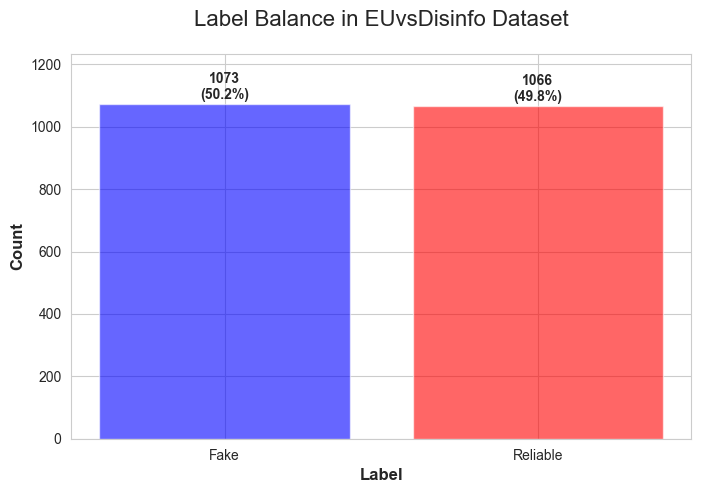

In [16]:
plot_label_distribution(df, dataset_name=dataset_name)

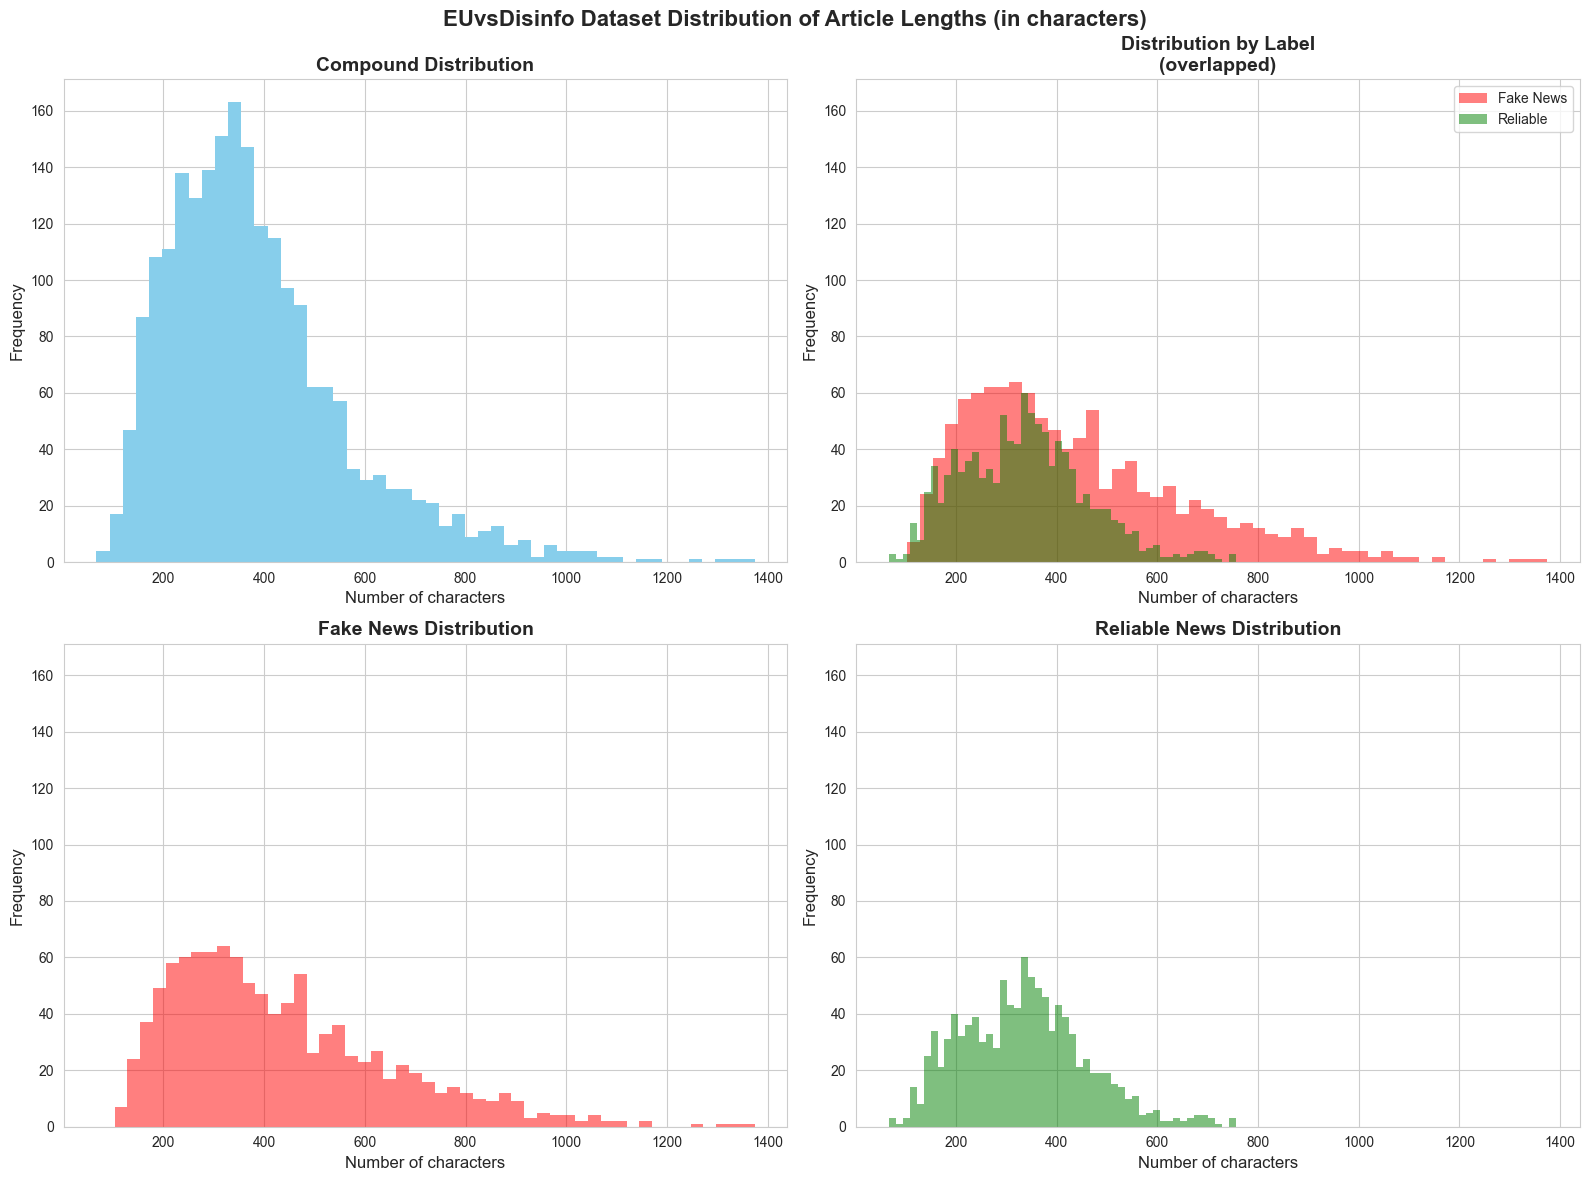

In [17]:
plot_article_length_distribution(df, dataset_name)

### Tokens Analysis


In [18]:
dataset = Dataset(dataset_name,
                  data_path=dataset_path).init(random_state=rd_seed)

2025-05-16 14:09:47,400 - Dataset - INFO - mlflow is not active, could not log the params: {'dataset_name': 'euvsdisinfo', 'train_pct': 0.7, 'val_pct': 0.15}
2025-05-16 14:09:47,401 - Dataset - INFO - mlflow is not active, could not log the params: {'dataset_signature': 'dataset(dn=euvsdisinfo,tp=0.7,vp=0.15);pipeline([])'}
2025-05-16 14:09:47,402 - Dataset - INFO - {'dataset_name': 'euvsdisinfo', 'train_pct': 0.7, 'val_pct': 0.15}
2025-05-16 14:09:47,403 - Dataset - INFO - mlflow is not active, could not log the params: {'preprocessing_pipeline_name': 'empty', 'preprocessing_pipeline_representation': "<PreprocessingPipeline 'empty': []>", 'preprocessing_pipeline': []}
2025-05-16 14:09:47,404 - Dataset - INFO - Prepared dataset does not exist, computing from scratch.
2025-05-16 14:09:47,425 - Dataset - INFO - Initializing preprocessing pipeline: <PreprocessingPipeline 'empty': []>
2025-05-16 14:09:47,426 - Dataset - INFO - artifacts path is none, skipping saving.


In [19]:
train_set_data = dataset.train_set
train_set_data.dataset.head()

,article,label
816,Politicians across Europe have warned that the...,1
187,Nato secretary general Jens Stoltenberg has sa...,1
619,A team of inspectors from the United Nations n...,1
1855,West has turned a blind eye to the genocide in...,0
158,A Russian court has ordered the arrest of tele...,1


#### NLTK tokenizer

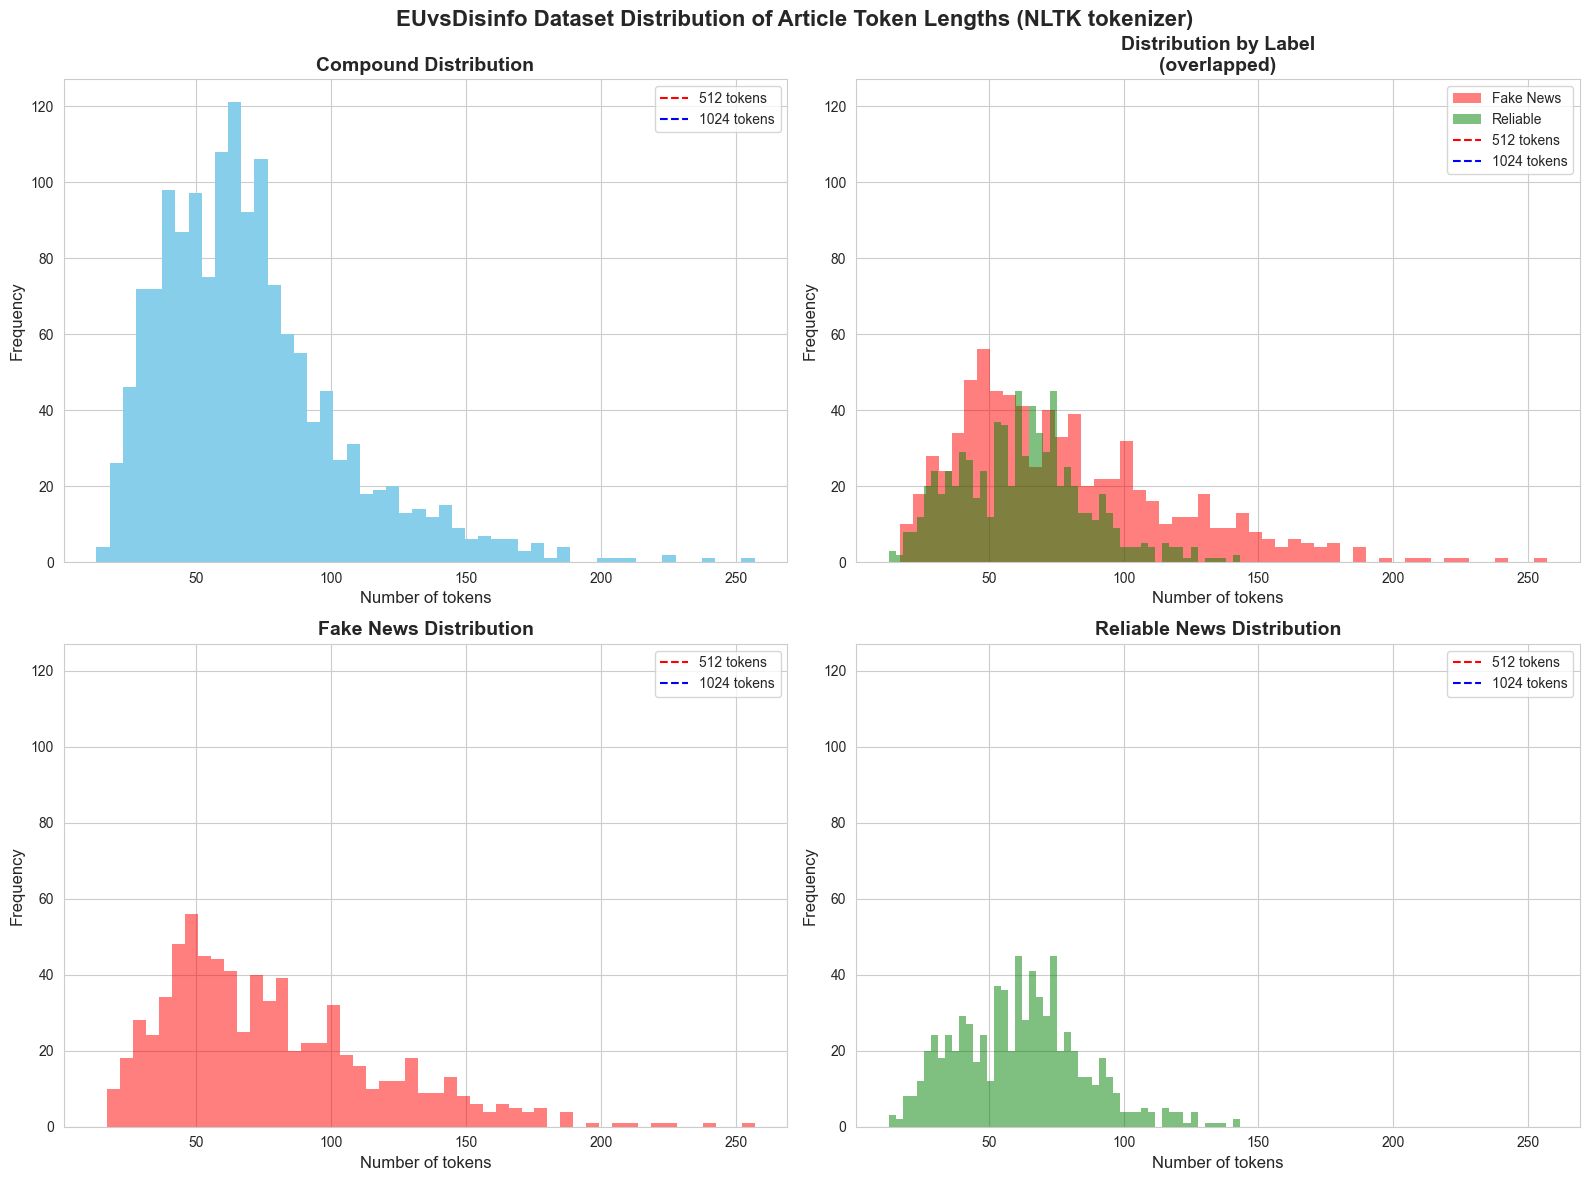

In [20]:
tokenizer = NLTKTokenizer(language='czech')
tokenized_train_set = tokenizer.preprocess(train_set_data.copy())

plot_token_length_distribution(tokenized_train_set.dataset,
                               dataset_name,
                               tokenizer_name='NLTK')

#### BERT Tokenizer

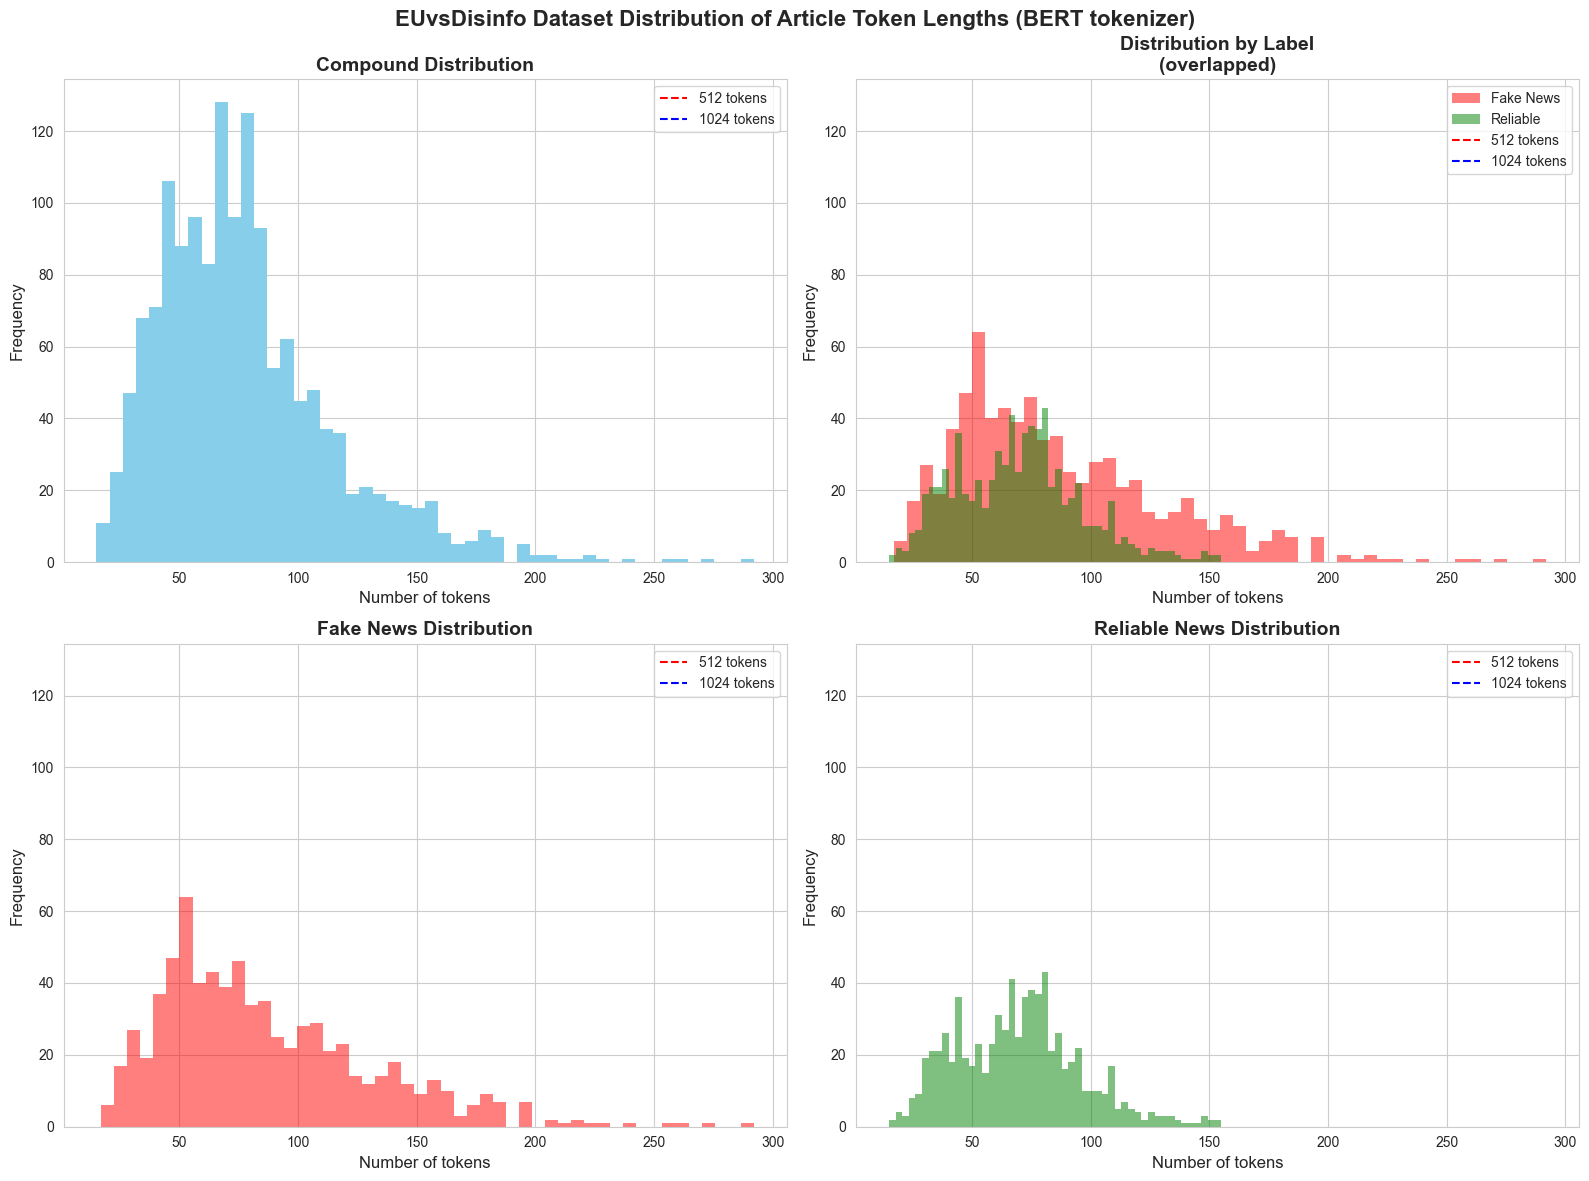

In [21]:
tokenizer = BERTTokenizer().init()
tokenized_train_set = tokenizer.preprocess(train_set_data.copy())

plot_token_length_distribution(tokenized_train_set.dataset,
                               dataset_name,
                               tokenizer_name='BERT')

#### GPT1 Tokenizer

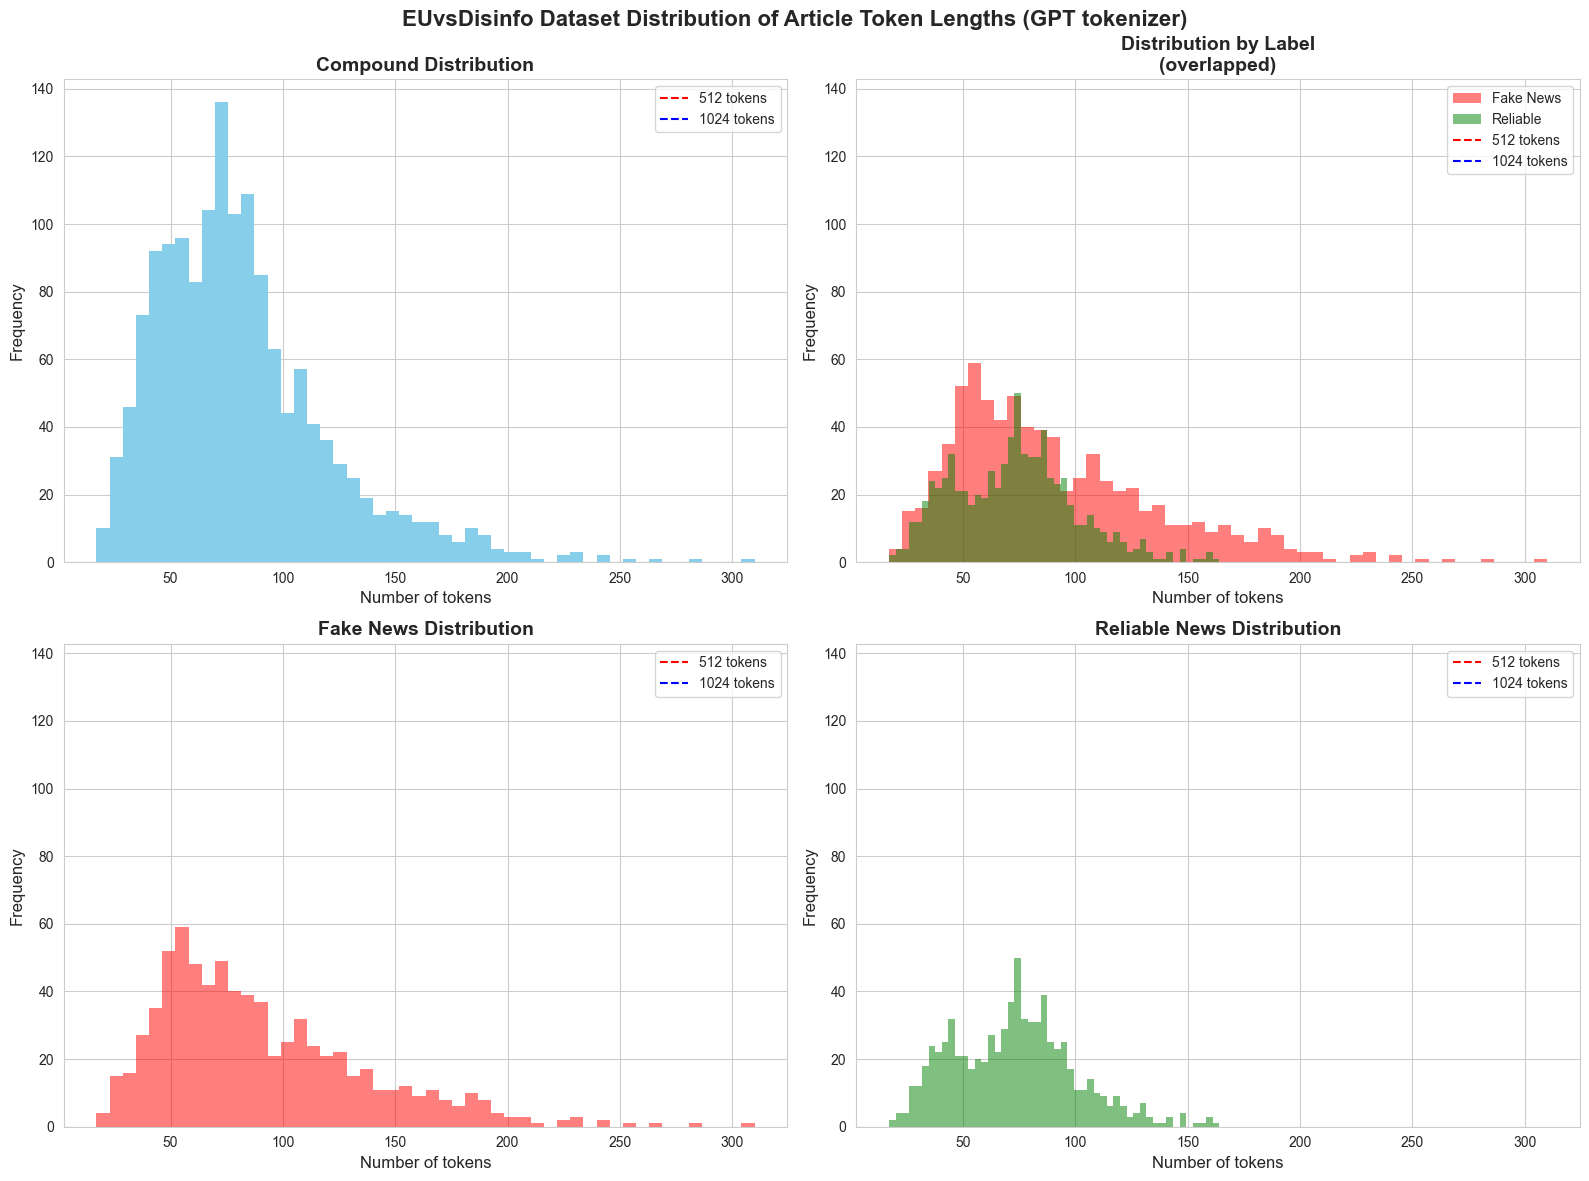

In [22]:
tokenizer = GPT1_Tokenizer().init()
tokenized_train_set = tokenizer.preprocess(train_set_data.copy())

plot_token_length_distribution(tokenized_train_set.dataset,
                               dataset_name,
                               tokenizer_name='GPT')